<a href="https://colab.research.google.com/github/meeera0/PhiUSIIL_Algorithm_Comparison/blob/main/CSBP711_PhiUSIIL_Algorithm_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phishing Website Detection: Dataset Audit and Algorithm Comparison

**Course:** CSBP711 — Advanced Artificial Intelligence, Fall 2026  
**Authors:** Meera Alalawi and Shamma Alalawi  
**Dataset:** PhiUSIIL Phishing URL (Website), UCI Repository

## Objective
Compare classification algorithms fairly, investigate how the dataset
influences their performance, and test an explanation using a controlled
feature ablation.

## Research Question
How well do phishing classifiers generalize to unseen domains, and how
much does their performance depend on the URLSimilarityIndex feature?

## Reproducibility
This notebook will document the dataset source and licence, data checks,
splits, preprocessing, random seeds, model settings, and measured results.
All reported results will be generated by running this notebook.

## 1. Setup and Dataset Download

Load the original dataset from UCI and record the download time and
software versions. Preserve all columns for the data audit.

Source: https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset  
Licence: Creative Commons Attribution 4.0 (CC BY 4.0)  
Original labels: 0 = phishing, 1 = legitimate.

In [ ]:
# Install the UCI dataset downloader
%pip -q install ucimlrepo

import random
import platform
from datetime import datetime, timezone
from importlib.metadata import version

import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Reuse these seeds throughout our experiments
SEED = 42
EXPERIMENT_SEEDS = [42, 123, 2026]

random.seed(SEED)
np.random.seed(SEED)

# Download the original data, including identifiers needed for our audit
dataset = fetch_ucirepo(id=967)
df_raw = dataset.data.original.copy(deep=True)

# Record provenance and environment
run_metadata = {
    "dataset": "PhiUSIIL Phishing URL (Website)",
    "uci_id": 967,
    "source": "https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset",
    "licence": "CC BY 4.0",
    "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": version("scikit-learn"),
    "ucimlrepo": version("ucimlrepo"),
    "seeds": EXPERIMENT_SEEDS,
}

# Basic loading checks; no cleaning or feature removal yet
assert not df_raw.empty, "The downloaded dataset is empty."
assert {"URL", "Domain", "label"}.issubset(df_raw.columns), \
    "Expected columns are missing. Inspect the downloaded data."

print("Dataset loaded successfully!")
print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")
print(f"\nOriginal label counts:\n{df_raw['label'].value_counts().sort_index()}")
print("\nSoftware versions:")
for key in ["python", "pandas", "numpy", "scikit-learn", "ucimlrepo"]:
    print(f"  {key}: {run_metadata[key]}")

display(df_raw.head(3))

Dataset loaded successfully!
Rows:    235,795
Columns: 56

Original label counts:
label
0    100945
1    134850
Name: count, dtype: int64

Software versions:
  python: 3.13.15
  pandas: 2.2.3
  numpy: 2.1.3
  scikit-learn: 1.6.1
  ucimlrepo: 0.0.7


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


## 2. Data Quality Audit

Check class balance, missing and blank values, infinite numeric values,
constant columns, duplicate records, repeated URLs, and conflicting labels.

Identifiers can hide duplicate records, so duplicates are also checked
after excluding FILENAME. Repeated domains will be investigated before
creating the train/test splits. No records are modified in this step.

In [ ]:
# 1. Class balance
class_balance = (
    df_raw["label"].value_counts().sort_index()
    .rename_axis("label").reset_index(name="records")
)
class_balance["class"] = class_balance["label"].map(
    {0: "Phishing", 1: "Legitimate"}
)
class_balance["percentage"] = (
    100 * class_balance["records"] / len(df_raw)
).round(2)

print("CLASS BALANCE")
display(class_balance[["label", "class", "records", "percentage"]])

# 2. Column-level checks
text_cols = df_raw.select_dtypes(include=["object", "string"]).columns
numeric_cols = df_raw.select_dtypes(include=np.number).columns

blank_counts = pd.Series(0, index=df_raw.columns, dtype="int64")
for col in text_cols:
    blank_counts[col] = int(
        df_raw[col].astype("string").str.strip().eq("").fillna(False).sum()
    )

infinite_counts = pd.Series(0, index=df_raw.columns, dtype="int64")
infinite_counts.loc[numeric_cols] = (
    np.isinf(df_raw[numeric_cols]).sum().astype("int64")
)

column_audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "blank_strings": blank_counts,
    "infinite": infinite_counts,
    "unique_nonmissing": df_raw.nunique(dropna=True),
})
column_audit.index.name = "column"

# 3. Duplicate checks
# "Extra rows" counts copies beyond the first occurrence.
without_filename = df_raw.drop(columns=["FILENAME"], errors="ignore")

# Strip surrounding whitespace only; URL paths can be case-sensitive.
url_keys = df_raw["URL"].astype("string").str.strip()
valid_urls = url_keys.notna() & url_keys.ne("")

url_label_counts = (
    pd.DataFrame({
        "url_key": url_keys[valid_urls],
        "label": df_raw.loc[valid_urls, "label"],
    })
    .groupby("url_key")["label"].nunique()
)
conflicting_urls = url_label_counts[url_label_counts > 1]

# These are supplied hostnames, not yet registrable-domain groups.
domain_keys = (
    df_raw["Domain"].astype("string").str.strip().str.lower()
)
valid_domains = domain_keys.notna() & domain_keys.ne("")

audit_summary = pd.Series({
    "Rows": len(df_raw),
    "Columns": df_raw.shape[1],
    "Missing cells": int(column_audit["missing"].sum()),
    "Blank text cells": int(column_audit["blank_strings"].sum()),
    "Infinite numeric cells": int(column_audit["infinite"].sum()),
    "Columns with <=1 nonmissing value": int(
        (column_audit["unique_nonmissing"] <= 1).sum()
    ),
    "Exact duplicate extra rows": int(df_raw.duplicated().sum()),
    "Duplicate extra rows excluding FILENAME": int(
        without_filename.duplicated().sum()
    ),
    "Repeated URL extra rows": int(
        url_keys[valid_urls].duplicated().sum()
    ),
    "Unique URLs with conflicting labels": len(conflicting_urls),
    "Unique supplied domains": domain_keys[valid_domains].nunique(),
    "Repeated supplied-domain extra rows": int(
        domain_keys[valid_domains].duplicated().sum()
    ),
}, name="value")

print("\nDATA QUALITY SUMMARY")
display(audit_summary.to_frame())

print("\nCOLUMN DETAILS")
display(column_audit)

CLASS BALANCE


,label,class,records,percentage
0,0,Phishing,100945,42.81
1,1,Legitimate,134850,57.19



DATA QUALITY SUMMARY


,value
Rows,235795
Columns,56
Missing cells,0
Blank text cells,0
Infinite numeric cells,0
Columns with <=1 nonmissing value,0
Exact duplicate extra rows,0
Duplicate extra rows excluding FILENAME,0
Repeated URL extra rows,425
Unique URLs with conflicting labels,0



COLUMN DETAILS


,dtype,missing,blank_strings,infinite,unique_nonmissing
column,,,,,
FILENAME,object,0,0,0,235795
URL,object,0,0,0,235370
URLLength,int64,0,0,0,482
Domain,object,0,0,0,220086
DomainLength,int64,0,0,0,101
IsDomainIP,int64,0,0,0,2
TLD,object,0,0,0,695
URLSimilarityIndex,float64,0,0,0,36360
CharContinuationRate,float64,0,0,0,898


## 3. Remove Repeated URLs and Define Model Inputs

The audit found no missing, blank, or infinite values, no constant
columns, and no exact duplicate records.

There were 425 additional occurrences of URLs, with no conflicting
labels. We retain the first occurrence in the original file order.
This is a deterministic choice, not a claim that it is the newest record.

We use the 50 supplied numeric predictors, including binary indicators.
FILENAME, URL, Domain, TLD, and Title are excluded from model inputs.
URL and Domain remain available for grouping and leakage checks.
Excluding TLD is a modelling choice, not evidence that it causes leakage.

Original labels are preserved: 0 = phishing, 1 = legitimate.

In [ ]:
# Start from the untouched original data every time this cell is run.
assert df_raw["label"].isin([0, 1]).all(), "Unexpected target labels."
assert len(conflicting_urls) == 0, "Resolve conflicting URL labels first."

# Keep one record per URL, using original file order.
# Preserve case: URL paths may be case-sensitive.
url_key = df_raw["URL"].astype("string").str.strip()
assert url_key.notna().all() and url_key.ne("").all(), "Missing/blank URLs."

keep_rows = ~url_key.duplicated(keep="first")

df = df_raw.loc[keep_rows].copy()
df.insert(0, "source_row_id", df.index)
df = df.reset_index(drop=True)

# Explicitly define model inputs; retain metadata in df for later checks.
excluded_columns = {
    "source_row_id", "FILENAME", "URL", "Domain", "TLD", "Title", "label"
}
feature_columns = [
    col for col in df.columns if col not in excluded_columns
]

assert len(feature_columns) == 50, "Unexpected number of predictors."
assert all(
    pd.api.types.is_numeric_dtype(df[col]) for col in feature_columns
), "A selected predictor is not numeric."

# These are unprocessed data: scaling will occur after splitting.
X = df[feature_columns].copy()
y = df["label"].astype(int).copy()

cleaning_summary = pd.DataFrame({
    "Measure": [
        "Original records",
        "Repeated URL entries removed",
        "Retained records",
        "Model predictors",
    ],
    "Value": [
        len(df_raw),
        len(df_raw) - len(df),
        len(df),
        X.shape[1],
    ],
})

print("CLEANING SUMMARY")
display(cleaning_summary)

retained_balance = (
    y.value_counts().sort_index()
    .rename_axis("label").reset_index(name="records")
)
retained_balance["class"] = retained_balance["label"].map(
    {0: "Phishing", 1: "Legitimate"}
)
retained_balance["percentage"] = (
    100 * retained_balance["records"] / len(df)
).round(2)

print("\nCLASS BALANCE AFTER URL DEDUPLICATION")
display(retained_balance[["label", "class", "records", "percentage"]])

print("\nNo scaling, feature selection, or model training performed yet.")

CLEANING SUMMARY


,Measure,Value
0,Original records,235795
1,Repeated URL entries removed,425
2,Retained records,235370
3,Model predictors,50



CLASS BALANCE AFTER URL DEDUPLICATION


,label,class,records,percentage
0,0,Phishing,100520,42.71
1,1,Legitimate,134850,57.29



No scaling, feature selection, or model training performed yet.


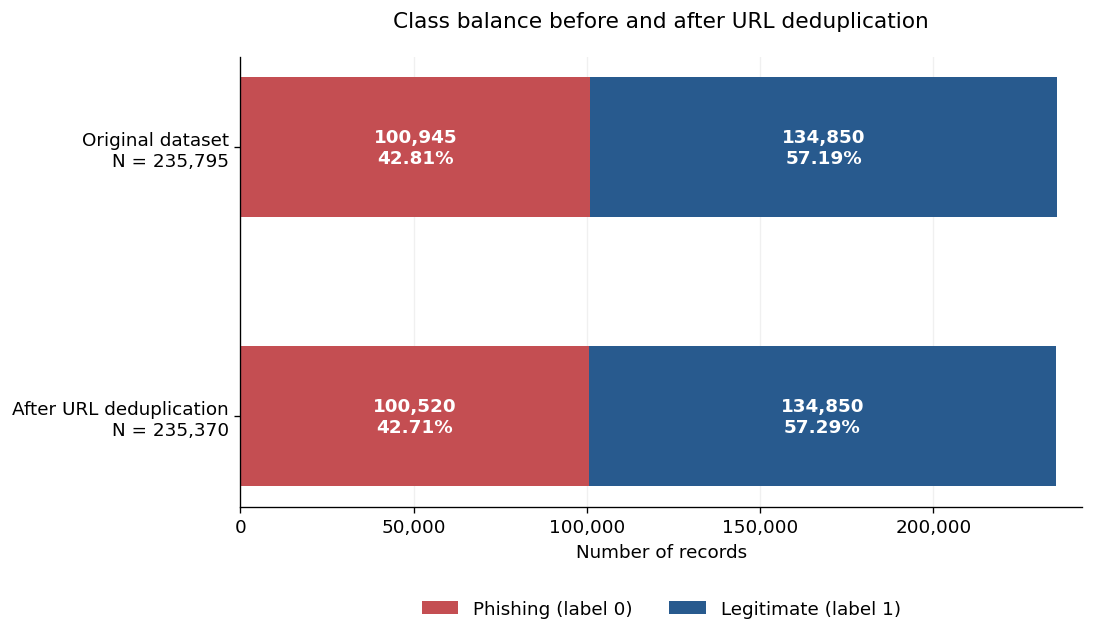

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Shared styling for this and subsequent figures.
FIGURE_DIR = Path("CSBP711_results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {
    "Phishing": "#C44E52",
    "Legitimate": "#285A8E",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

# Calculate directly from the original and cleaned data.
original_counts = df_raw["label"].value_counts()
cleaned_counts = df["label"].value_counts()

stages = ["Original dataset", "After URL deduplication"]
phishing_counts = [
    int(original_counts.get(0, 0)),
    int(cleaned_counts.get(0, 0)),
]
legitimate_counts = [
    int(original_counts.get(1, 0)),
    int(cleaned_counts.get(1, 0)),
]
totals = [
    phishing_counts[i] + legitimate_counts[i]
    for i in range(2)
]

fig, ax = plt.subplots(figsize=(9, 5.2), layout="constrained")
positions = np.arange(len(stages))

ax.barh(
    positions, phishing_counts,
    color=CLASS_COLORS["Phishing"],
    label="Phishing (label 0)", height=0.52,
)
ax.barh(
    positions, legitimate_counts, left=phishing_counts,
    color=CLASS_COLORS["Legitimate"],
    label="Legitimate (label 1)", height=0.52,
)

for i in range(2):
    for count, left in [
        (phishing_counts[i], 0),
        (legitimate_counts[i], phishing_counts[i]),
    ]:
        ax.text(
            left + count / 2, i,
            f"{count:,}\n{100 * count / totals[i]:.2f}%",
            ha="center", va="center",
            color="white", fontweight="bold",
        )

ax.set_yticks(
    positions,
    [f"{stage}\nN = {total:,}" for stage, total in zip(stages, totals)],
)
ax.invert_yaxis()
ax.set_xlim(0, max(totals) * 1.03)
ax.set_xlabel("Number of records")
ax.set_title("Class balance before and after URL deduplication", pad=18)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.18)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.17),
    ncol=2, frameon=False,
)

fig.savefig(
    FIGURE_DIR / "01_class_balance.png",
    bbox_inches="tight", facecolor="white",
)
fig.savefig(
    FIGURE_DIR / "01_class_balance.pdf",
    bbox_inches="tight", facecolor="white",
)
plt.show()

**Figure 1. Class balance before and after URL deduplication.**
Removing 425 repeated URL entries reduced phishing records from 100,945
to 100,520; legitimate records remained at 134,850. Phishing prevalence
changed slightly, from 42.81% to 42.71%. Both classes remain well represented.

## 4. Domain Groups for Leakage-Aware Splitting

Related subdomains must stay in the same partition.

We extract hostnames from URLs and group them by registrable domain,
using tldextract's bundled Public Suffix List. Private hosting suffixes
are not separated: all tenants of a shared parent such as blogspot.com
remain together. This is a conservative grouping choice.

IP addresses are grouped by address. Unrecognized suffixes retain the
full hostname and are flagged for review. Domain groups are metadata,
not model inputs. This prevents domain overlap but does not rule out
other forms of leakage or collection bias.

In [ ]:
%pip -q install tldextract

import ipaddress
from urllib.parse import urlsplit
from functools import lru_cache
import tldextract

# Use the bundled suffix list without fetching a changing online list.
extract_domain = tldextract.TLDExtract(
    suffix_list_urls=(),
    cache_dir=None,
    include_psl_private_domains=False,
)

run_metadata["tldextract"] = version("tldextract")
run_metadata["domain_grouping"] = (
    "Bundled PSL; private suffixes excluded; IPs grouped by address"
)

def get_hostname(url):
    """Parse locally; this does not visit the URL."""
    try:
        text = str(url).strip()
        parsed = urlsplit(text if "://" in text else "//" + text)
        host = parsed.hostname
        if not host:
            return None
        host = host.lower().rstrip(".")
        # Normalize internationalized domain names.
        return host.encode("idna").decode("ascii")
    except (ValueError, UnicodeError):
        return None

@lru_cache(maxsize=None)
def get_domain_group(host):
    if host is None:
        return (None, "parse_failure")

    try:
        address = ipaddress.ip_address(host)
        return (str(address), "ip_address")
    except ValueError:
        pass

    parts = extract_domain(host)
    if parts.domain and parts.suffix:
        return (
            f"{parts.domain}.{parts.suffix}",
            "registrable_domain",
        )

    return (host, "unrecognized_suffix")

# Store grouping metadata separately from the 50 predictors.
domain_metadata = pd.DataFrame(index=df.index)
domain_metadata["hostname"] = df["URL"].map(get_hostname)

group_details = domain_metadata["hostname"].map(get_domain_group)
domain_metadata[["domain_group", "grouping_method"]] = pd.DataFrame(
    group_details.tolist(), index=df.index
)

print("GROUPING METHODS")
display(
    domain_metadata["grouping_method"]
    .value_counts()
    .rename_axis("method")
    .to_frame("records")
)

group_sizes = domain_metadata["domain_group"].value_counts()

print(f"\nUnique domain groups: {len(group_sizes):,}")
print(f"Groups containing multiple records: {(group_sizes > 1).sum():,}")
print(f"Largest group: {group_sizes.max():,} records")

print("\nTEN LARGEST GROUPS")
display(group_sizes.head(10).rename_axis("domain_group").to_frame("records"))

# Show exceptions before deciding how to handle them.
exceptions = domain_metadata["grouping_method"].isin(
    ["parse_failure", "unrecognized_suffix"]
)
if exceptions.any():
    print("\nEXAMPLES TO REVIEW")
    display(domain_metadata.loc[exceptions].head(10))

assert X.shape[1] == 50, "Grouping metadata entered the model inputs!"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 4.4 MB/s eta 0:00:00
GROUPING METHODS


,records
method,
registrable_domain,234764
ip_address,606



Unique domain groups: 175,509
Groups containing multiple records: 5,964
Largest group: 5,718 records

TEN LARGEST GROUPS


,records
domain_group,
web.app,5718
firebaseapp.com,5546
repl.co,3746
weeblysite.com,3079
ipfs.io,1552
workers.dev,1423
square.site,1187
dweb.link,959
xsph.ru,928


## 5. Train, Validation, and Test Partitions

We use two reproducible group-based splits to allocate approximately
60% of domain groups to training, 20% to validation, and 20% to testing.

Actual record proportions may differ because domain groups vary in size.
The split is not stratified; class proportions are reported explicitly.

Training data fits the models and preprocessing. Validation data supports
development decisions. Test data is reserved for the final evaluation.

Shared hosting parents remain intact, so this evaluates a mixture of
unseen-domain and unseen-hosting-platform generalization.

The same partitions will be used for every model and its ablation.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from itertools import combinations

groups = domain_metadata["domain_group"].copy()

assert groups.notna().all(), "Some records have no domain group."
assert X.index.equals(y.index) and X.index.equals(groups.index)

# First: reserve approximately 20% of groups for final testing.
outer_split = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=SEED
)
development_idx, test_idx = next(
    outer_split.split(X, y, groups=groups)
)

# Second: reserve 25% of the remaining groups for validation.
# 25% of 80% = approximately 20% of all groups.
inner_split = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=SEED
)
train_relative, val_relative = next(
    inner_split.split(
        X.iloc[development_idx],
        y.iloc[development_idx],
        groups=groups.iloc[development_idx],
    )
)

train_idx = development_idx[train_relative]
val_idx = development_idx[val_relative]

split_indices = {
    "Train": train_idx,
    "Validation": val_idx,
    "Test": test_idx,
}

# Verify complete coverage with no repeated rows.
all_indices = np.concatenate(list(split_indices.values()))
assert len(all_indices) == len(df)
assert len(np.unique(all_indices)) == len(df)

# Verify that neither domains nor retained URLs cross partitions.
overlap_rows = []
url_keys_clean = df["URL"].astype("string").str.strip()

for left, right in combinations(split_indices, 2):
    left_idx = split_indices[left]
    right_idx = split_indices[right]

    domain_overlap = len(
        set(groups.iloc[left_idx]) & set(groups.iloc[right_idx])
    )
    url_overlap = len(
        set(url_keys_clean.iloc[left_idx])
        & set(url_keys_clean.iloc[right_idx])
    )

    overlap_rows.append({
        "Partitions": f"{left} / {right}",
        "Shared domain groups": domain_overlap,
        "Shared URLs": url_overlap,
    })
    assert domain_overlap == 0
    assert url_overlap == 0

# Report the actual split sizes and class proportions.
summary_rows = []
for name, idx in split_indices.items():
    labels = y.iloc[idx]
    assert labels.nunique() == 2, f"{name} is missing a class."

    summary_rows.append({
        "Partition": name,
        "Records": len(idx),
        "Records (%)": round(100 * len(idx) / len(df), 2),
        "Domain groups": groups.iloc[idx].nunique(),
        "Phishing": int((labels == 0).sum()),
        "Legitimate": int((labels == 1).sum()),
        "Phishing (%)": round(100 * (labels == 0).mean(), 2),
    })

split_summary = pd.DataFrame(summary_rows)
overlap_summary = pd.DataFrame(overlap_rows)

print("PARTITION SUMMARY")
display(split_summary)

print("\nOVERLAP CHECKS")
display(overlap_summary)

# Unscaled partitions: preprocessing will be fitted on training data only.
X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx].copy()
X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx].copy()
X_test, y_test = X.iloc[test_idx].copy(), y.iloc[test_idx].copy()

# Keep a reproducible record of each original row's assignment.
split_manifest = df[["source_row_id"]].copy()
split_manifest["domain_group"] = groups
split_manifest["partition"] = ""
for name, idx in split_indices.items():
    split_manifest.loc[idx, "partition"] = name

print("\nSplits created. No preprocessing or models have been fitted.")

PARTITION SUMMARY


,Partition,Records,Records (%),Domain groups,Phishing,Legitimate,Phishing (%)
0,Train,148453,63.07,105305,67330,81123,45.35
1,Validation,45028,19.13,35102,18247,26781,40.52
2,Test,41889,17.80,35102,14943,26946,35.67



OVERLAP CHECKS


,Partitions,Shared domain groups,Shared URLs
0,Train / Validation,0,0
1,Train / Test,0,0
2,Validation / Test,0,0



Splits created. No preprocessing or models have been fitted.


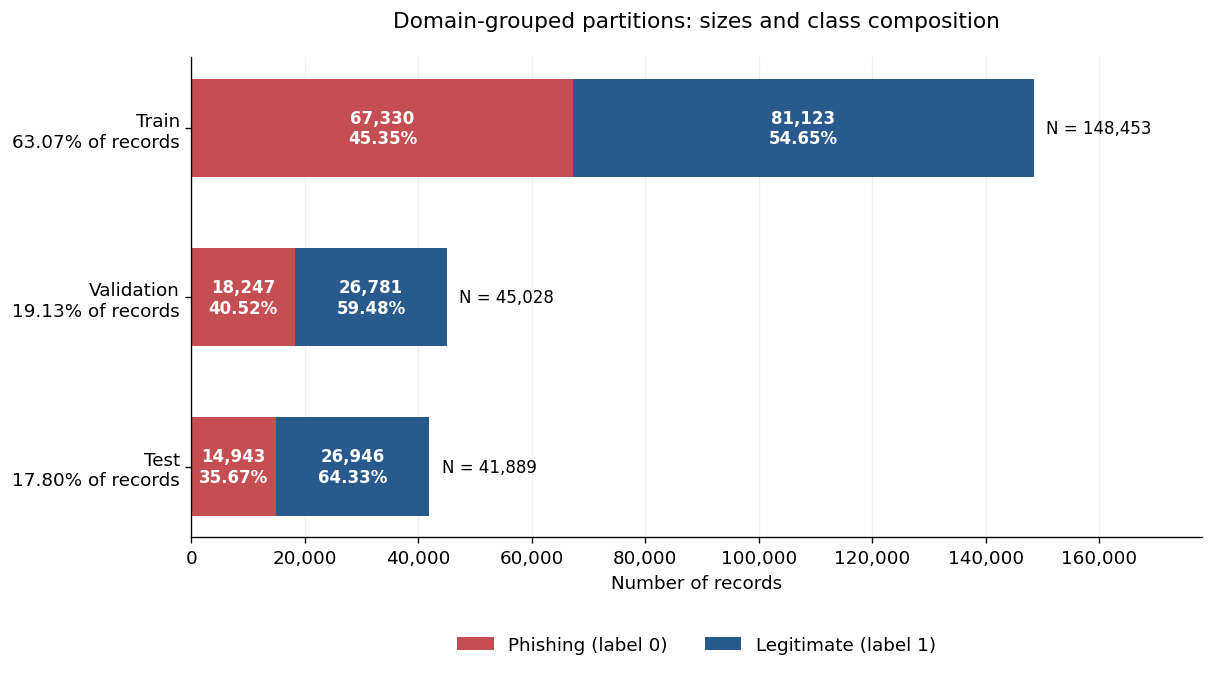

In [ ]:
# Figure 2: partition sizes and class composition.
partition_plot = (
    split_summary.set_index("Partition")
    .loc[["Train", "Validation", "Test"]]
)

fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
positions = np.arange(len(partition_plot))

phishing = partition_plot["Phishing"].to_numpy()
legitimate = partition_plot["Legitimate"].to_numpy()
totals = phishing + legitimate

ax.barh(
    positions, phishing,
    color=CLASS_COLORS["Phishing"],
    label="Phishing (label 0)", height=0.58,
)
ax.barh(
    positions, legitimate, left=phishing,
    color=CLASS_COLORS["Legitimate"],
    label="Legitimate (label 1)", height=0.58,
)

for i, total in enumerate(totals):
    for count, left in [
        (phishing[i], 0),
        (legitimate[i], phishing[i]),
    ]:
        ax.text(
            left + count / 2, i,
            f"{count:,}\n{100 * count / total:.2f}%",
            ha="center", va="center",
            color="white", fontweight="bold", fontsize=10,
        )

    ax.text(
        total + max(totals) * 0.015, i,
        f"N = {total:,}",
        ha="left", va="center", fontsize=10,
    )

ax.set_yticks(
    positions,
    [
        f"{name}\n{row['Records (%)']:.2f}% of records"
        for name, row in partition_plot.iterrows()
    ],
)
ax.invert_yaxis()
ax.set_xlim(0, max(totals) * 1.20)
ax.set_xlabel("Number of records")
ax.set_title(
    "Domain-grouped partitions: sizes and class composition",
    pad=18,
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.18)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.17),
    ncol=2, frameon=False,
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"02_partition_balance.{extension}",
        bbox_inches="tight", facecolor="white",
    )

plt.show()

**Figure 2. Record counts and class composition of the domain-grouped
partitions.** Training contains 148,453 records (63.07%), validation
45,028 (19.13%), and testing 41,889 (17.80%). Percentages inside the bars
show class proportions within each partition. Phishing prevalence varies
because whole domain groups, including large shared-hosting groups, remain
together. The overlap checks confirm zero shared domain groups and zero
shared retained URLs between partitions; they do not rule out other
sources of leakage.

## 6. Logistic Regression Baseline

Logistic regression tests how well a linear decision boundary separates
phishing and legitimate records using the 50 supplied predictors.

We standardize every predictor using training-set statistics only.
The same preprocessing procedure will be used for all compared models.

Configuration: L2 regularization, C=1, lbfgs solver, maximum 2,000
iterations, and random seed 42. We check for convergence warnings.

The primary comparison metric is phishing F1 (positive label = 0).
We also report precision, recall, false-positive rate, accuracy, and MCC.

Training time includes fitting the scaler and classifier. Pipeline size
is measured using uncompressed pickle serialization, including the fitted
scaler. These are validation results, not final test results.

In [ ]:
import pickle
import warnings
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)

# Reusable evaluation function for all our classifiers.
def evaluate_classifier(model, X_eval, y_eval):
    predictions = model.predict(X_eval)

    # Order: legitimate (negative), phishing (positive).
    tn, fp, fn, tp = confusion_matrix(
        y_eval, predictions, labels=[1, 0]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_eval, predictions),
        "Phishing precision": precision_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "Phishing recall": recall_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "Phishing F1": f1_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "False-positive rate": fp / (fp + tn),
        "MCC": matthews_corrcoef(y_eval, predictions),
        "Errors": int(fp + fn),
        "Missed phishing": int(fn),
        "False phishing alerts": int(fp),
    }

# The pipeline learns scaling statistics exclusively from X_train.
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        random_state=SEED,
    )),
])

print("Training logistic regression...", flush=True)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    start = perf_counter()
    baseline.fit(X_train, y_train)
    baseline_train_seconds = perf_counter() - start

# Show any warnings rather than silently hiding them.
for warning in caught:
    print(f"{warning.category.__name__}: {warning.message}")

convergence_warning = any(
    issubclass(w.category, ConvergenceWarning) for w in caught
)

baseline_result = {
    "Model": "Logistic regression",
    "Evaluation": "Validation",
    **evaluate_classifier(baseline, X_val, y_val),
    "Train seconds": baseline_train_seconds,
    "Pipeline KiB": len(
        pickle.dumps(baseline, protocol=5)
    ) / 1024,
    "Convergence warning": convergence_warning,
}

# Retain results and models for the later comparison table.
validation_results = {"Logistic regression": baseline_result}
fitted_models = {"Logistic regression": baseline}

print("\nBASELINE VALIDATION RESULTS")
display(pd.DataFrame([baseline_result]).T.rename(columns={0: "Value"}))

fitted_lr = baseline.named_steps["model"]
print(f"\nSolver iterations: {fitted_lr.n_iter_.max()}")
print(
    "Classifier coefficients + intercept:",
    fitted_lr.coef_.size + fitted_lr.intercept_.size,
)
print("Final test set has not been evaluated.")

Training logistic regression...

BASELINE VALIDATION RESULTS


,Value
Model,Logistic regression
Evaluation,Validation
Accuracy,0.9998
Phishing precision,1.0
Phishing recall,0.999507
Phishing F1,0.999753
False-positive rate,0.0
MCC,0.999585
Errors,9
Missed phishing,9



Solver iterations: 13
Classifier coefficients + intercept: 51
Final test set has not been evaluated.


## 7. Validation Diagnostic: Remove URLSimilarityIndex

The logistic-regression baseline made nine validation errors with all
50 predictors, despite domain-separated partitions.

Hypothesis: URLSimilarityIndex contributes substantially to this strong
performance. Removing it is expected to reduce phishing F1 and increase
errors. A small change would suggest that other features retain strong
predictive information.

We repeat logistic regression using 49 predictors, keeping the same
training/validation records, preprocessing procedure, and model settings.
The scaler and classifier are fitted again using training data only.

This diagnostic measures feature dependence; it does not establish
whether the feature contains leakage. The final test set remains unused.

In [ ]:
from sklearn.base import clone

ablation_features = [
    col for col in feature_columns if col != "URLSimilarityIndex"
]
assert len(ablation_features) == 49

# clone copies settings but discards fitted parameters.
baseline_ablated = clone(baseline)

print("Training logistic regression without URLSimilarityIndex...", flush=True)

with warnings.catch_warnings(record=True) as caught_ablation:
    warnings.simplefilter("always")
    start = perf_counter()
    baseline_ablated.fit(X_train[ablation_features], y_train)
    ablation_train_seconds = perf_counter() - start

for warning in caught_ablation:
    print(f"{warning.category.__name__}: {warning.message}")

baseline_ablation_result = {
    "Model": "Logistic regression",
    "Evaluation": "Validation",
    **evaluate_classifier(
        baseline_ablated, X_val[ablation_features], y_val
    ),
    "Train seconds": ablation_train_seconds,
    "Pipeline KiB": len(
        pickle.dumps(baseline_ablated, protocol=5)
    ) / 1024,
    "Convergence warning": any(
        issubclass(w.category, ConvergenceWarning)
        for w in caught_ablation
    ),
}

baseline_ablation_comparison = pd.DataFrame([
    {"Features": "All 50", **baseline_result},
    {"Features": "Without URLSimilarityIndex (49)",
     **baseline_ablation_result},
])

print("\nVALIDATION ABLATION COMPARISON")
display(
    baseline_ablation_comparison[[
        "Features", "Phishing F1", "Phishing recall",
        "False-positive rate", "Errors", "Missed phishing",
        "False phishing alerts", "Train seconds",
        "Convergence warning",
    ]].round(6)
)

print(
    "\nChange in validation errors:",
    baseline_ablation_result["Errors"] - baseline_result["Errors"],
)
print(
    "Change in phishing F1:",
    f'{baseline_ablation_result["Phishing F1"] - baseline_result["Phishing F1"]:+.6f}',
)
print("Final test set has not been evaluated.")

Training logistic regression without URLSimilarityIndex...

VALIDATION ABLATION COMPARISON


,Features,Phishing F1,Phishing recall,False-positive rate,Errors,Missed phishing,False phishing alerts,Train seconds,Convergence warning
0,All 50,0.999753,0.999507,0.000000,9,9,0,2.541900,False
1,Without URLSimilarityIndex (49),0.999123,0.998904,0.000448,32,20,12,2.935237,False



Change in validation errors: 23
Change in phishing F1: -0.000630
Final test set has not been evaluated.


## 8. Tree-Ensemble Comparison on Validation Data

The logistic-regression ablation increased validation errors from 9 to 32.
Phishing F1 decreased by approximately 0.063 percentage points, remaining
very high. URLSimilarityIndex contributes predictive information, but the
remaining features also support near-perfect linear classification.

We next compare:
- Random forest: 100 trees, minimum leaf size 2.
- Gradient boosting: 100 boosting stages, learning rate 0.1,
  maximum tree depth 3.

These are fixed starting configurations, not exhaustively tuned models.
Both use all 50 predictors, the same partitions and seed, and the same
training-only standardization procedure as logistic regression.

Training time includes preprocessing. Serialized pipeline size uses
the same uncompressed pickle protocol. Test data remains unused.

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

tree_estimators = {
    "Random forest": RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=1,
    ),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=SEED,
    ),
}

for name, estimator in tree_estimators.items():
    model_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

    print(f"Training {name}...", flush=True)

    start = perf_counter()
    model_pipeline.fit(X_train, y_train)
    train_seconds = perf_counter() - start

    result = {
        "Model": name,
        "Evaluation": "Validation",
        **evaluate_classifier(model_pipeline, X_val, y_val),
        "Train seconds": train_seconds,
        "Pipeline KiB": len(
            pickle.dumps(model_pipeline, protocol=5)
        ) / 1024,
        "Convergence warning": False,
    }

    fitted_models[name] = model_pipeline
    validation_results[name] = result

    print(
        f"Finished: {result['Errors']} validation errors; "
        f"{train_seconds:.2f} seconds.",
        flush=True,
    )

comparison_columns = [
    "Model", "Phishing F1", "Phishing recall",
    "False-positive rate", "Errors",
    "Train seconds", "Pipeline KiB",
]

validation_table = pd.DataFrame(validation_results.values())

print("\nVALIDATION COMPARISON — ALL 50 FEATURES")
display(
    validation_table[comparison_columns]
    .sort_values("Phishing F1", ascending=False)
    .round(6)
)

print("\nFinal test set has not been evaluated.")

Training Random forest...
Finished: 5 validation errors; 19.64 seconds.
Training Gradient boosting...
Finished: 2 validation errors; 58.48 seconds.

VALIDATION COMPARISON — ALL 50 FEATURES


,Model,Phishing F1,Phishing recall,False-positive rate,Errors,Train seconds,Pipeline KiB
2,Gradient boosting,0.999945,0.999890,0.0,2,58.479452,87.804688
1,Random forest,0.999863,0.999726,0.0,5,19.643427,1827.492188
0,Logistic regression,0.999753,0.999507,0.0,9,2.541900,3.503906



Final test set has not been evaluated.


## 9. Neural Network Comparison

We use a multilayer perceptron (MLP) with one hidden layer containing
100 neurons, ReLU activation, and the Adam optimizer.

This provides a nonlinear neural-network comparison using the same
50 predictors, training records, validation records, and standardization
procedure as the other models.

Configuration: hidden_layer_sizes=(100,), alpha=0.0001,
learning_rate_init=0.001, batch_size=256, maximum 200 epochs,
and random seed 42.

Early stopping on an internal random validation split is disabled to
avoid introducing a separate split that ignores domain groups. Training
can stop when training loss fails to improve by the specified tolerance.

We record warnings and the actual number of training epochs.
The final test set remains unused.

In [ ]:
from sklearn.neural_network import MLPClassifier

neural_network = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=False,
        tol=1e-4,
        n_iter_no_change=10,
        random_state=SEED,
    )),
])

print("Training neural network...", flush=True)

with warnings.catch_warnings(record=True) as nn_warnings:
    warnings.simplefilter("always")
    start = perf_counter()
    neural_network.fit(X_train, y_train)
    nn_train_seconds = perf_counter() - start

for warning in nn_warnings:
    print(f"{warning.category.__name__}: {warning.message}")

nn_result = {
    "Model": "Neural network",
    "Evaluation": "Validation",
    **evaluate_classifier(neural_network, X_val, y_val),
    "Train seconds": nn_train_seconds,
    "Pipeline KiB": len(
        pickle.dumps(neural_network, protocol=5)
    ) / 1024,
    "Convergence warning": any(
        issubclass(w.category, ConvergenceWarning)
        for w in nn_warnings
    ),
}

fitted_models["Neural network"] = neural_network
validation_results["Neural network"] = nn_result

nn = neural_network.named_steps["model"]
nn_parameter_count = sum(
    weights.size for weights in nn.coefs_
) + sum(
    biases.size for biases in nn.intercepts_
)

print(f"\nTraining epochs completed: {nn.n_iter_}")
print(f"Trainable weights and biases: {nn_parameter_count:,}")
print(f"Convergence warning: {nn_result['Convergence warning']}")

validation_table = pd.DataFrame(validation_results.values())

print("\nFOUR-MODEL VALIDATION COMPARISON — ALL 50 FEATURES")
display(
    validation_table[comparison_columns]
    .sort_values("Phishing F1", ascending=False)
    .round(6)
)

print("\nFinal test set has not been evaluated.")

Training neural network...

Training epochs completed: 16
Trainable weights and biases: 5,201
Convergence warning: False

FOUR-MODEL VALIDATION COMPARISON — ALL 50 FEATURES


,Model,Phishing F1,Phishing recall,False-positive rate,Errors,Train seconds,Pipeline KiB
2,Gradient boosting,0.999945,0.999890,0.0,2,58.479452,87.804688
1,Random forest,0.999863,0.999726,0.0,5,19.643427,1827.492188
3,Neural network,0.999863,0.999726,0.0,5,26.523537,172.250977
0,Logistic regression,0.999753,0.999507,0.0,9,2.541900,3.503906



Final test set has not been evaluated.


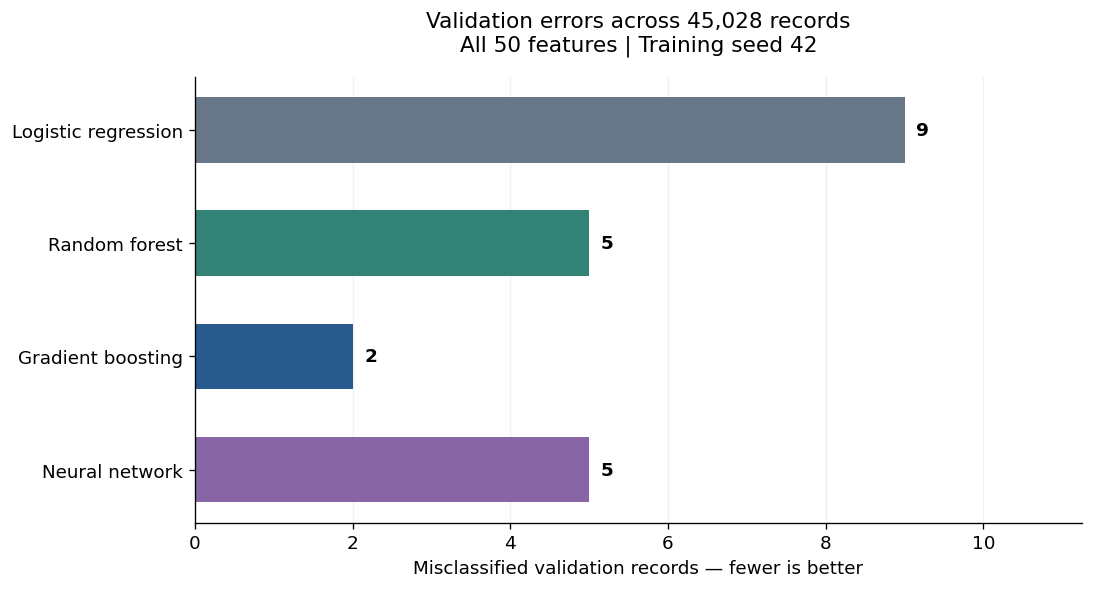

In [ ]:
# Figure 3: validation errors using all 50 features, seed 42.
MODEL_ORDER = [
    "Logistic regression",
    "Random forest",
    "Gradient boosting",
    "Neural network",
]

MODEL_COLORS = {
    "Logistic regression": "#687787",
    "Random forest": "#328276",
    "Gradient boosting": "#285A8E",
    "Neural network": "#8866A5",
}

validation_plot = (
    pd.DataFrame(validation_results.values())
    .set_index("Model")
    .loc[MODEL_ORDER]
)

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")

bars = ax.barh(
    MODEL_ORDER,
    validation_plot["Errors"],
    color=[MODEL_COLORS[name] for name in MODEL_ORDER],
    height=0.58,
)

ax.bar_label(bars, fmt="%.0f", padding=7, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, max(1, validation_plot["Errors"].max()) * 1.25)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Misclassified validation records — fewer is better")
ax.set_title(
    f"Validation errors across {len(y_val):,} records\n"
    "All 50 features | Training seed 42",
    pad=16,
)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.18)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"03_validation_errors.{extension}",
        bbox_inches="tight", facecolor="white",
    )

plt.show()

**Figure 3. Four-model validation comparison using all 50 predictors
and training seed 42.** Gradient boosting made two errors, random forest
and the neural network each made five, and logistic regression made nine.
All errors were missed phishing records; no legitimate records were
flagged as phishing. Error counts reveal differences obscured by rounded
near-perfect F1 scores. These small differences on one validation
partition do not establish a statistically reliable advantage.

## 10. Four-Model Feature Ablation

We remove URLSimilarityIndex and retrain each model using the same
records, preprocessing procedure, hyperparameters, and random seed.

The logistic-regression ablation has already been completed and is reused.

Working explanation: the supplied features provide strong class separation,
with URLSimilarityIndex contributing additional information. Our prediction
is that removing it will increase errors, while nonlinear models may retain
an advantage by using relationships among the remaining features.

We compare phishing F1, error counts, and rankings before and after removal.
A ranking change is not guaranteed. If it does not occur, we report that
rather than claiming the ablation demonstrated a change.

These are exploratory validation results. The test set remains unused.

In [ ]:
# Reuse the completed logistic-regression ablation.
ablation_results = {
    "Logistic regression": baseline_ablation_result
}
ablated_models = {
    "Logistic regression": baseline_ablated
}

for name in ["Random forest", "Gradient boosting", "Neural network"]:
    # Copy settings, discarding all fitted parameters.
    model_pipeline = clone(fitted_models[name])

    print(f"Training {name} without URLSimilarityIndex...", flush=True)

    with warnings.catch_warnings(record=True) as recorded_warnings:
        warnings.simplefilter("always")
        start = perf_counter()
        model_pipeline.fit(X_train[ablation_features], y_train)
        train_seconds = perf_counter() - start

    for warning in recorded_warnings:
        print(f"{warning.category.__name__}: {warning.message}")

    result = {
        "Model": name,
        "Evaluation": "Validation",
        **evaluate_classifier(
            model_pipeline, X_val[ablation_features], y_val
        ),
        "Train seconds": train_seconds,
        "Pipeline KiB": len(
            pickle.dumps(model_pipeline, protocol=5)
        ) / 1024,
        "Convergence warning": any(
            issubclass(w.category, ConvergenceWarning)
            for w in recorded_warnings
        ),
    }

    ablation_results[name] = result
    ablated_models[name] = model_pipeline

    print(
        f"Finished: {result['Errors']} errors; "
        f"convergence warning = {result['Convergence warning']}",
        flush=True,
    )

# Build the before/after comparison using full-precision scores.
before = pd.DataFrame(validation_results.values()).set_index("Model")
after = pd.DataFrame(ablation_results.values()).set_index("Model")
after = after.reindex(before.index)

ablation_comparison = pd.DataFrame({
    "F1: all 50": before["Phishing F1"],
    "F1: without USI": after["Phishing F1"],
    "F1 change": after["Phishing F1"] - before["Phishing F1"],
    "Errors: all 50": before["Errors"],
    "Errors: without USI": after["Errors"],
    "Extra errors": after["Errors"] - before["Errors"],
    "Rank: all 50": before["Phishing F1"].rank(
        ascending=False, method="min"
    ).astype(int),
    "Rank: without USI": after["Phishing F1"].rank(
        ascending=False, method="min"
    ).astype(int),
    "Convergence warning": after["Convergence warning"],
})

print("\nVALIDATION ABLATION — USI = URLSimilarityIndex")
display(ablation_comparison.round(6))

print("\nFinal test set has not been evaluated.")

Training Random forest without URLSimilarityIndex...
Finished: 10 errors; convergence warning = False
Training Gradient boosting without URLSimilarityIndex...
Finished: 14 errors; convergence warning = False
Training Neural network without URLSimilarityIndex...
Finished: 10 errors; convergence warning = False

VALIDATION ABLATION — USI = URLSimilarityIndex


,F1: all 50,F1: without USI,F1 change,Errors: all 50,Errors: without USI,Extra errors,Rank: all 50,Rank: without USI,Convergence warning
Model,,,,,,,,,
Logistic regression,0.999753,0.999123,-0.000630,9,32,23,4,4,False
Random forest,0.999863,0.999726,-0.000137,5,10,5,2,1,False
Gradient boosting,0.999945,0.999616,-0.000329,2,14,12,1,3,False
Neural network,0.999863,0.999726,-0.000137,5,10,5,2,2,False



Final test set has not been evaluated.


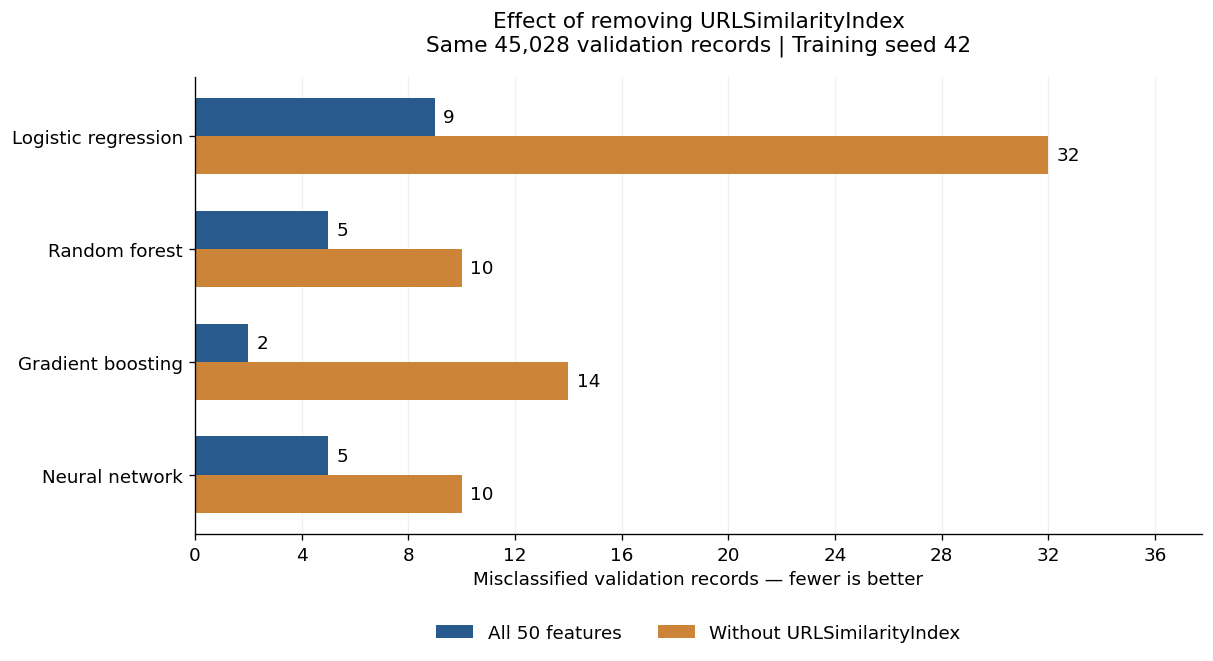

In [ ]:
# Figure 4 — Validation errors before and after removing USI
# Uses existing results; no models are trained.

ablation_plot = ablation_comparison.loc[MODEL_ORDER]

positions = np.arange(len(MODEL_ORDER))
bar_height = 0.34

fig, ax = plt.subplots(figsize=(10, 5.4), layout="constrained")

bars_full = ax.barh(
    positions - bar_height / 2,
    ablation_plot["Errors: all 50"],
    height=bar_height,
    color="#285A8E",
    label="All 50 features"
)

bars_without = ax.barh(
    positions + bar_height / 2,
    ablation_plot["Errors: without USI"],
    height=bar_height,
    color="#CC8438",
    label="Without URLSimilarityIndex"
)

ax.bar_label(bars_full, fmt="%.0f", padding=5)
ax.bar_label(bars_without, fmt="%.0f", padding=5)

ax.set_yticks(positions)
ax.set_yticklabels(MODEL_ORDER)
ax.invert_yaxis()

largest_count = ablation_plot[
    ["Errors: all 50", "Errors: without USI"]
].to_numpy().max()

ax.set_xlim(0, largest_count * 1.18)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Misclassified validation records — fewer is better")
ax.set_title(
    "Effect of removing URLSimilarityIndex\n"
    f"Same {len(y_val):,} validation records | Training seed 42",
    pad=16
)

ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.18)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"04_validation_ablation.{extension}",
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()

**Figure 4.** Validation feature ablation using training seed 42. Removing URLSimilarityIndex increased errors for every model: logistic regression from 9 to 32, random forest from 5 to 10, gradient boosting from 2 to 14, and the neural network from 5 to 10. Gradient boosting lost its lead in error count, indicating that its relative performance depends partly on the available features. However, all models remained highly accurate without this feature, so URLSimilarityIndex alone does not explain the dataset’s near-perfect results. This ablation demonstrates feature dependence; it does not establish data leakage.

## 11. Validation Stability Across Training Seeds

For seed 42, removing URLSimilarityIndex moved gradient boosting from
first to third place on validation F1. All four models made more errors.

We repeat both feature conditions with the previously specified seeds
123 and 2026. The domain partitions and hyperparameters remain fixed.

This checks sensitivity to model-training randomness. It does not measure
variation across alternative domain partitions. Logistic regression with
lbfgs is effectively deterministic here, so its results may not change.

We report every run and summarize mean F1, standard deviation, and error
counts. We do not select the best-performing seed.

In [ ]:
# Reuse the completed seed-42 runs.
stability_rows = []

for condition, results in [
    ("All 50", validation_results),
    ("Without USI", ablation_results),
]:
    for name, result in results.items():
        stability_rows.append({
            "Model": name,
            "Features": condition,
            "Seed": SEED,
            **{
                key: result[key]
                for key in [
                    "Phishing F1", "Errors",
                    "Missed phishing", "False phishing alerts",
                    "Convergence warning",
                ]
            },
        })

# Additional runs use identical partitions and model settings.
for seed in [s for s in EXPERIMENT_SEEDS if s != SEED]:
    for condition, columns in [
        ("All 50", feature_columns),
        ("Without USI", ablation_features),
    ]:
        for name, template in fitted_models.items():
            print(f"Seed {seed} | {condition} | {name}", flush=True)

            pipeline = clone(template)
            pipeline.set_params(model__random_state=seed)

            with warnings.catch_warnings(record=True) as run_warnings:
                warnings.simplefilter("always")
                pipeline.fit(X_train[columns], y_train)

            for warning in run_warnings:
                print(f"{warning.category.__name__}: {warning.message}")

            metrics = evaluate_classifier(
                pipeline, X_val[columns], y_val
            )

            stability_rows.append({
                "Model": name,
                "Features": condition,
                "Seed": seed,
                "Phishing F1": metrics["Phishing F1"],
                "Errors": metrics["Errors"],
                "Missed phishing": metrics["Missed phishing"],
                "False phishing alerts": metrics["False phishing alerts"],
                "Convergence warning": any(
                    issubclass(w.category, ConvergenceWarning)
                    for w in run_warnings
                ),
            })

stability_runs = pd.DataFrame(stability_rows)

stability_summary = (
    stability_runs.groupby(["Model", "Features"], sort=False)
    .agg(
        Mean_F1=("Phishing F1", "mean"),
        SD_F1=("Phishing F1", "std"),
        Mean_errors=("Errors", "mean"),
        Min_errors=("Errors", "min"),
        Max_errors=("Errors", "max"),
        Any_convergence_warning=("Convergence warning", "any"),
    )
    .reset_index()
)

print("\nVALIDATION STABILITY — THREE TRAINING SEEDS")
display(stability_summary.round(8))

print("\nERROR COUNTS BY SEED")
display(
    stability_runs.pivot(
        index="Model", columns=["Features", "Seed"], values="Errors"
    )
)

print("\nFinal test set has not been evaluated.")

Seed 123 | All 50 | Logistic regression
Seed 123 | All 50 | Random forest
Seed 123 | All 50 | Gradient boosting
Seed 123 | All 50 | Neural network
Seed 123 | Without USI | Logistic regression
Seed 123 | Without USI | Random forest
Seed 123 | Without USI | Gradient boosting
Seed 123 | Without USI | Neural network
Seed 2026 | All 50 | Logistic regression
Seed 2026 | All 50 | Random forest
Seed 2026 | All 50 | Gradient boosting
Seed 2026 | All 50 | Neural network
Seed 2026 | Without USI | Logistic regression
Seed 2026 | Without USI | Random forest
Seed 2026 | Without USI | Gradient boosting
Seed 2026 | Without USI | Neural network

VALIDATION STABILITY — THREE TRAINING SEEDS


,Model,Features,Mean_F1,SD_F1,Mean_errors,Min_errors,Max_errors,Any_convergence_warning
0,Logistic regression,All 50,0.999753,0.000000,9.000000,9,9,False
1,Random forest,All 50,0.999900,0.000042,3.666667,2,5,False
2,Gradient boosting,All 50,0.999945,0.000000,2.000000,2,2,False
3,Neural network,All 50,0.999881,0.000032,4.333333,3,5,False
4,Logistic regression,Without USI,0.999123,0.000000,32.000000,32,32,False
5,Random forest,Without USI,0.999653,0.000063,12.666667,10,14,False
6,Gradient boosting,Without USI,0.999616,0.000000,14.000000,14,14,False
7,Neural network,Without USI,0.999726,0.000027,10.000000,9,11,False



ERROR COUNTS BY SEED


Features,All 50,Without USI,All 50,Without USI,All 50,Without USI
Seed,42,42,123,123,2026,2026
Model,,,,,,
Gradient boosting,2,14,2,14,2,14
Logistic regression,9,32,9,32,9,32
Neural network,5,10,3,9,5,11
Random forest,5,10,4,14,2,14



Final test set has not been evaluated.


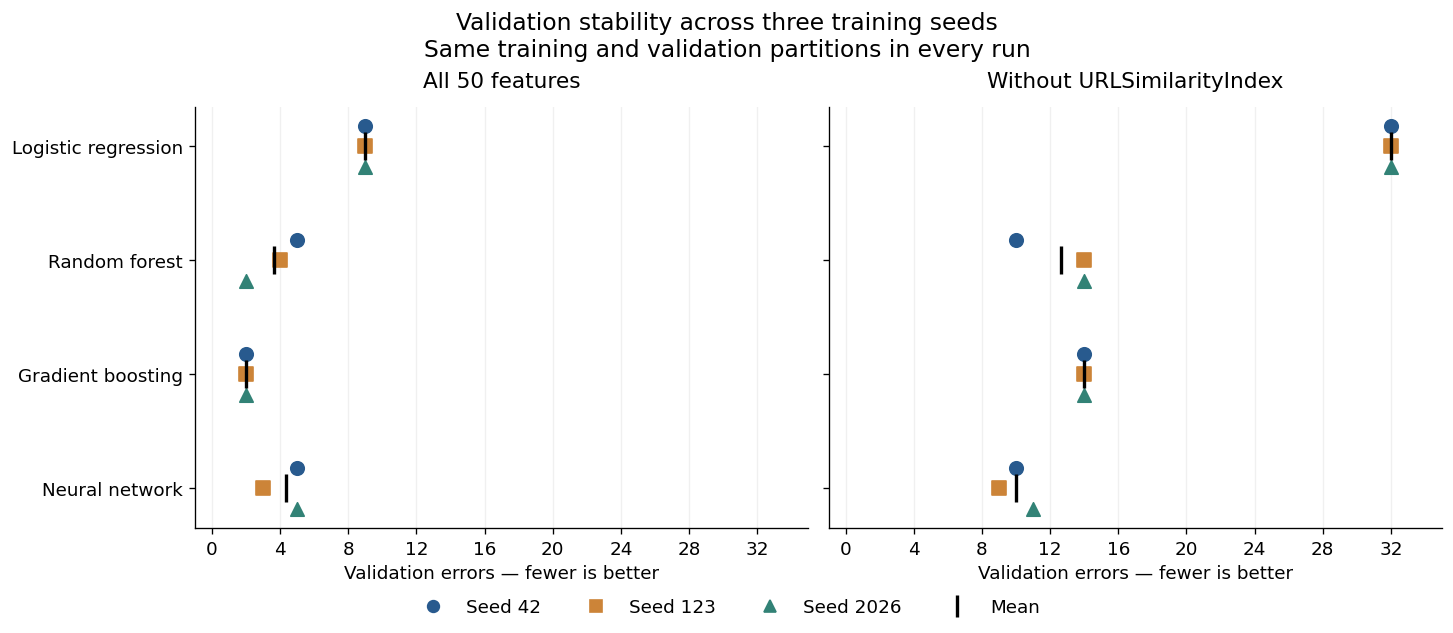

In [ ]:
# Figure 5 — Validation stability across training seeds
# Uses saved results; no training is performed.

from matplotlib.lines import Line2D

seed_styles = {
    42:   {"color": "#285A8E", "marker": "o", "offset": -0.18},
    123:  {"color": "#CC8438", "marker": "s", "offset": 0.00},
    2026: {"color": "#328276", "marker": "^", "offset": 0.18},
}

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5.2),
    sharex=True, sharey=True,
    layout="constrained"
)

positions = np.arange(len(MODEL_ORDER))

for ax, condition, title in zip(
    axes,
    ["All 50", "Without USI"],
    ["All 50 features", "Without URLSimilarityIndex"]
):
    subset = stability_runs[
        stability_runs["Features"] == condition
    ]

    for seed, style in seed_styles.items():
        values = (
            subset[subset["Seed"] == seed]
            .set_index("Model")
            .loc[MODEL_ORDER, "Errors"]
        )

        ax.scatter(
            values,
            positions + style["offset"],
            color=style["color"],
            marker=style["marker"],
            s=65,
            zorder=3
        )

    means = (
        subset.groupby("Model")["Errors"]
        .mean()
        .reindex(MODEL_ORDER)
    )

    ax.scatter(
        means, positions,
        marker="|", s=300, linewidths=2,
        color="black", zorder=4
    )

    ax.set_title(title, pad=12)
    ax.set_xlabel("Validation errors — fewer is better")
    ax.set_yticks(positions)
    ax.set_yticklabels(MODEL_ORDER)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.18)

axes[0].invert_yaxis()
axes[0].set_xlim(-1, stability_runs["Errors"].max() + 3)

legend_handles = [
    Line2D(
        [0], [0],
        marker=style["marker"],
        color=style["color"],
        linestyle="None",
        markersize=7,
        label=f"Seed {seed}"
    )
    for seed, style in seed_styles.items()
]

legend_handles.append(
    Line2D(
        [0], [0],
        marker="|", color="black",
        linestyle="None",
        markersize=13, markeredgewidth=2,
        label="Mean"
    )
)

fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=4,
    frameon=False
)

fig.suptitle(
    "Validation stability across three training seeds\n"
    "Same training and validation partitions in every run",
    fontsize=14
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"05_validation_seed_stability.{extension}",
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()

**Figure 5.** Validation stability across training seeds 42, 123, and 2026. Each coloured marker represents one run; black marks indicate mean error counts. Markers are vertically offset for readability. With all features, gradient boosting consistently made two errors, although random forest matched it in one run. Without URLSimilarityIndex, the neural network had the lowest mean error count (10), followed by random forest (12.67), gradient boosting (14), and logistic regression (32). These runs assess training randomness on one fixed partition; they do not measure variability across different data splits.

## 12. Final Test Evaluation — Fixed Seed 42

Development is complete. Model configurations, feature sets, domain
partitions, and the primary metric (phishing F1) are now fixed.

Across three training seeds on the validation partition, gradient boosting
had the highest mean F1 with all features. The neural network had the
highest mean F1 without URLSimilarityIndex.

We now evaluate the eight existing seed-42 pipelines on the held-out test
partition. They remain fitted on training data only; validation data is
not added to training. This preserves the exact pipelines and training
costs already measured.

The main comparison uses all 50 predictors. The paired ablation removes
only URLSimilarityIndex. No settings or thresholds will be adjusted using
test results.

The test contains unseen domain groups under our conservative grouping
policy. It is not an independent or temporally newer dataset.

In [ ]:
test_rows = []

conditions = [
    ("All 50", fitted_models, validation_results, feature_columns),
    ("Without USI", ablated_models, ablation_results, ablation_features),
]

# Evaluate the existing seed-42 pipelines; do not fit anything here.
for condition, models, training_records, columns in conditions:
    for name, model in models.items():
        assert model.named_steps["model"].random_state == SEED

        metrics = evaluate_classifier(model, X_test[columns], y_test)

        test_rows.append({
            "Model": name,
            "Features": condition,
            "Seed": SEED,
            "Evaluation": "Test",
            **metrics,
            "Train seconds": training_records[name]["Train seconds"],
            "Pipeline KiB": training_records[name]["Pipeline KiB"],
        })

test_results = pd.DataFrame(test_rows)

main_test_table = (
    test_results[test_results["Features"] == "All 50"]
    .sort_values("Phishing F1", ascending=False)
    .reset_index(drop=True)
)

print("FINAL TEST RESULTS — ALL 50 FEATURES, SEED 42")
display(
    main_test_table[[
        "Model", "Phishing F1", "Phishing precision",
        "Phishing recall", "False-positive rate", "MCC",
        "Errors", "Train seconds", "Pipeline KiB",
    ]].round(8)
)

full_test = (
    test_results[test_results["Features"] == "All 50"]
    .set_index("Model")
)
ablated_test = (
    test_results[test_results["Features"] == "Without USI"]
    .set_index("Model")
    .reindex(full_test.index)
)

test_ablation_comparison = pd.DataFrame({
    "F1: all 50": full_test["Phishing F1"],
    "F1: without USI": ablated_test["Phishing F1"],
    "F1 change": (
        ablated_test["Phishing F1"] - full_test["Phishing F1"]
    ),
    "Errors: all 50": full_test["Errors"],
    "Errors: without USI": ablated_test["Errors"],
    "Rank: all 50": full_test["Phishing F1"].rank(
        ascending=False, method="min"
    ).astype(int),
    "Rank: without USI": ablated_test["Phishing F1"].rank(
        ascending=False, method="min"
    ).astype(int),
})

print("\nFINAL TEST ABLATION — SEED 42")
display(test_ablation_comparison.round(8))

# Retain predictions for later error analysis and reproducibility.
test_predictions = df.iloc[test_idx][["source_row_id"]].copy()
test_predictions["true_label"] = y_test.to_numpy()

for condition, models, _, columns in conditions:
    for name, model in models.items():
        test_predictions[f"{name} | {condition}"] = model.predict(
            X_test[columns]
        )

print(f"\nEvaluated {len(y_test):,} test records per pipeline.")
print("No models were retrained and no settings were changed.")

FINAL TEST RESULTS — ALL 50 FEATURES, SEED 42


,Model,Phishing F1,Phishing precision,Phishing recall,False-positive rate,MCC,Errors,Train seconds,Pipeline KiB
0,Random forest,1.000000,1.0,1.000000,0.0,1.000000,0,19.643427,1827.492188
1,Gradient boosting,1.000000,1.0,1.000000,0.0,1.000000,0,58.479452,87.804688
2,Neural network,0.999900,1.0,0.999799,0.0,0.999844,3,26.523537,172.250977
3,Logistic regression,0.999833,1.0,0.999665,0.0,0.999740,5,2.541900,3.503906



FINAL TEST ABLATION — SEED 42


,F1: all 50,F1: without USI,F1 change,Errors: all 50,Errors: without USI,Rank: all 50,Rank: without USI
Model,,,,,,,
Logistic regression,0.999833,0.998795,-0.001038,5,36,4,4
Random forest,1.000000,0.999732,-0.000268,0,8,1,1
Gradient boosting,1.000000,0.999665,-0.000335,0,10,1,2
Neural network,0.999900,0.999464,-0.000435,3,16,3,3



Evaluated 41,889 test records per pipeline.
No models were retrained and no settings were changed.


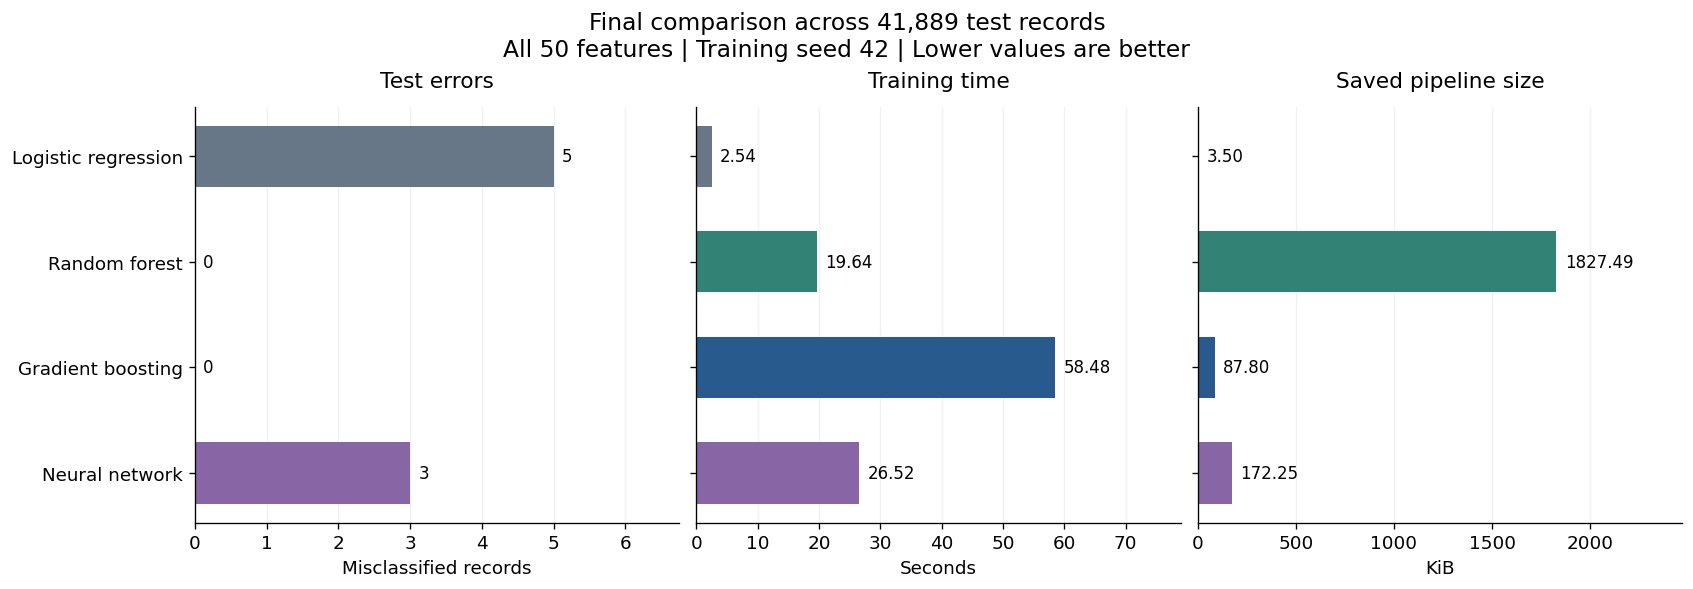

In [ ]:
# Figure 6 — Final test performance and computational cost
# Uses existing results; no retraining or new predictions.

test_plot = (
    main_test_table
    .set_index("Model")
    .loc[MODEL_ORDER]
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4.8),
    sharey=True,
    layout="constrained"
)

panels = [
    ("Errors", "Test errors", "Misclassified records", "%.0f"),
    ("Train seconds", "Training time", "Seconds", "%.2f"),
    ("Pipeline KiB", "Saved pipeline size", "KiB", "%.2f"),
]

positions = np.arange(len(MODEL_ORDER))
colors = [MODEL_COLORS[name] for name in MODEL_ORDER]

for ax, (column, title, xlabel, label_format) in zip(axes, panels):
    values = test_plot[column].to_numpy()

    bars = ax.barh(
        positions, values,
        color=colors, height=0.58
    )

    ax.bar_label(
        bars,
        fmt=label_format,
        padding=5,
        fontsize=10
    )

    ax.set_yticks(positions)
    ax.set_yticklabels(MODEL_ORDER)
    ax.set_xlim(0, max(float(values.max()), 1) * 1.35)
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.18)

axes[0].invert_yaxis()
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.suptitle(
    f"Final comparison across {len(y_test):,} test records\n"
    "All 50 features | Training seed 42 | Lower values are better",
    fontsize=14
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"06_final_test_comparison.{extension}",
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()

**Figure 6.** Final test performance and computational cost using all 50 features and training seed 42. Random forest and gradient boosting both made zero errors on 41,889 test records; the neural network missed three phishing records and logistic regression missed five. Random forest trained approximately three times faster than gradient boosting, while gradient boosting’s saved pipeline was approximately 21 times smaller. Logistic regression was the fastest and smallest model. Training times are the original measured fit times; sizes represent serialized pipelines, including preprocessing and retained estimator state. Zero observed test errors do not guarantee perfect performance on future data.

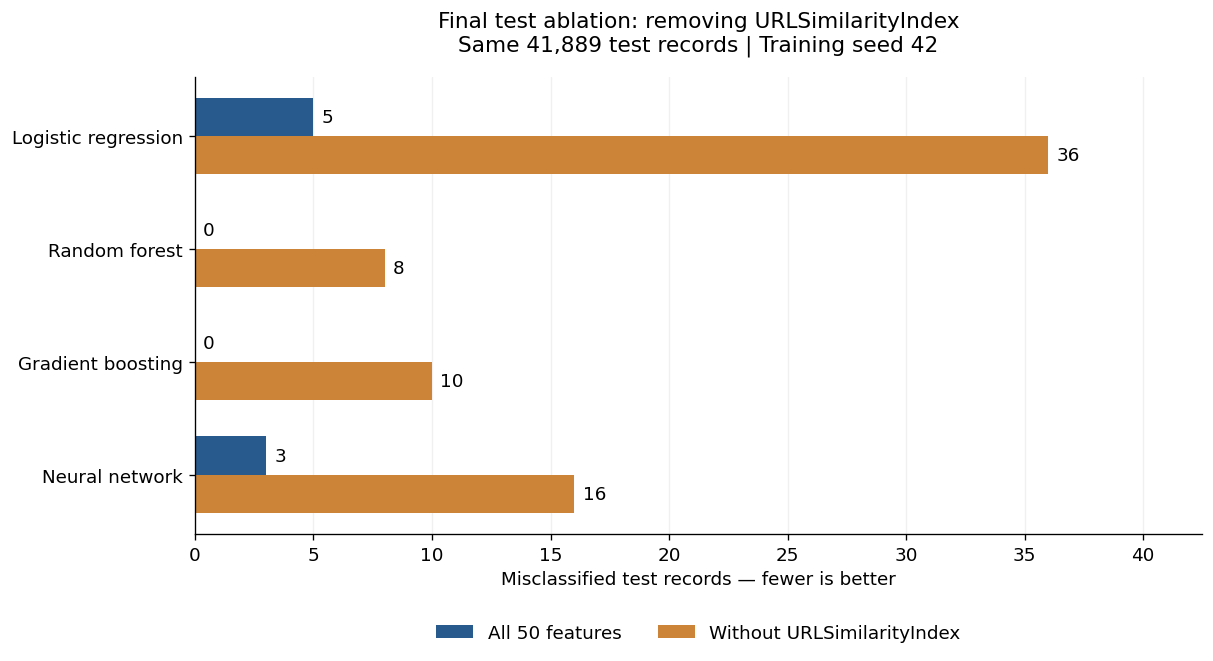

In [ ]:
# Figure 7 — Final test ablation
# Uses saved results; no training or new predictions.

final_ablation_plot = test_ablation_comparison.loc[MODEL_ORDER]

positions = np.arange(len(MODEL_ORDER))
bar_height = 0.34

fig, ax = plt.subplots(figsize=(10, 5.4), layout="constrained")

bars_full = ax.barh(
    positions - bar_height / 2,
    final_ablation_plot["Errors: all 50"],
    height=bar_height,
    color="#285A8E",
    label="All 50 features"
)

bars_without = ax.barh(
    positions + bar_height / 2,
    final_ablation_plot["Errors: without USI"],
    height=bar_height,
    color="#CC8438",
    label="Without URLSimilarityIndex"
)

ax.bar_label(bars_full, fmt="%.0f", padding=5)
ax.bar_label(bars_without, fmt="%.0f", padding=5)

ax.set_yticks(positions)
ax.set_yticklabels(MODEL_ORDER)
ax.invert_yaxis()

largest_count = final_ablation_plot[
    ["Errors: all 50", "Errors: without USI"]
].to_numpy().max()

ax.set_xlim(0, largest_count * 1.18)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("Misclassified test records — fewer is better")
ax.set_title(
    "Final test ablation: removing URLSimilarityIndex\n"
    f"Same {len(y_test):,} test records | Training seed 42",
    pad=16
)

ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.18)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"07_final_test_ablation.{extension}",
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()

**Figure 7.** Final test ablation using training seed 42. Removing URLSimilarityIndex increased test errors from 5 to 36 for logistic regression, 0 to 8 for random forest, 0 to 10 for gradient boosting, and 3 to 16 for the neural network. The full-feature tie between the two tree ensembles became a small advantage for random forest. All four models benefited from the feature, but their strong remaining performance indicates that other predictors also carry substantial class information. The neural network’s lowest mean validation error count without this feature did not transfer to the seed-42 test comparison. These findings are limited to one fixed domain-group split.

## 13. Results and Interpretation

### Main comparison
Random forest and gradient boosting tied for the highest test phishing F1
(1.0), with zero observed errors across 41,889 held-out records. The neural
network made three errors, and logistic regression made five.

Random forest trained in 19.64 seconds versus 58.48 seconds for gradient
boosting. Gradient boosting had the smaller serialized pipeline:
87.80 KiB versus 1,827.49 KiB. These are single-run timings on this runtime.

### Feature ablation
Removing URLSimilarityIndex increased test errors to 8 for random forest,
10 for gradient boosting, 16 for the neural network, and 36 for logistic
regression. The ablation broke the leading tie in favour of random forest.

This supports the conclusion that URLSimilarityIndex contributes useful
predictive information. However, performance remained very high without
it, indicating that the remaining feature set also carries strong signal.

The neural network's highest mean validation F1 without USI did not
translate into the highest test F1. Validation rankings should therefore
not be treated as guaranteed test rankings.

### Explanation and limits
The engineered feature representation permits near-perfect classification
even with a linear baseline. Threshold effects and interactions among
features are a plausible explanation for the small tree-ensemble advantage,
but the single-feature ablation does not isolate or prove that mechanism.

Domain groups and retained URLs do not overlap across partitions.
Nevertheless, all records come from the same dataset, and supplied
reference-based features may carry collection-specific information.
Feature-construction leakage has not been ruled out by domain separation.

Training-seed stability was assessed on one fixed validation split.
Final test results use the originally chosen seed 42. Zero observed test
errors do not imply zero future errors or perfect real-world detection.

The near-perfect baseline also limits how convincingly this dataset meets
the assignment's requirement for a non-trivial task.

## 14. Export Results and Figures

Save the experiment tables, split assignments, test predictions, software versions, model settings, and seven figures for reproducibility. This step does not train or evaluate any models.

In [ ]:
# Export existing results and all eight figures.
# No training or evaluation is performed.

import json
import platform
import shutil
from pathlib import Path
from importlib.metadata import version
from google.colab import files

EXPORT_DIR = Path("CSBP711_results")
EXPORT_DIR.mkdir(exist_ok=True)

# Check that all eight figures exist in both formats.
figure_stems = [
    "01_class_balance",
    "02_partition_balance",
    "03_validation_errors",
    "04_validation_ablation",
    "05_validation_seed_stability",
    "06_final_test_comparison",
    "07_final_test_ablation",
    "08_training_feature_separation",
]

missing_figures = [
    f"{stem}.{extension}"
    for stem in figure_stems
    for extension in ["png", "pdf"]
    if not (
        EXPORT_DIR / "figures" / f"{stem}.{extension}"
    ).exists()
]

assert not missing_figures, (
    f"Missing figure files: {missing_figures}. "
    "Run the corresponding figure cells first."
)

# Preserve meaningful table indexes as ordinary CSV columns.
tables = {
    "data_quality_summary": audit_summary.reset_index(),
    "column_details": column_audit.reset_index(),
    "cleaning_summary": cleaning_summary,
    "class_balance_after_cleaning": retained_balance,
    "partition_summary": split_summary,
    "overlap_checks": overlap_summary,
    "validation_all_features": pd.DataFrame(
        validation_results.values()
    ),
    "validation_without_USI": pd.DataFrame(
        ablation_results.values()
    ),
    "validation_ablation": ablation_comparison.reset_index(),
    "validation_seed_runs": stability_runs,
    "validation_seed_summary": stability_summary,
    "final_test_all_features": main_test_table,
    "final_test_all_runs": pd.DataFrame(test_results),
    "final_test_ablation": test_ablation_comparison.reset_index(),
    "split_manifest": split_manifest,
    "test_predictions": test_predictions,
    "training_feature_separation": feature_separation,
}

for name, table in tables.items():
    table.to_csv(
        EXPORT_DIR / f"{name}.csv",
        index=False
    )

# Record installed software versions.
packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "ucimlrepo",
    "tldextract",
    "matplotlib",
    "joblib",
    "threadpoolctl",
]

package_versions = {
    name: version(name)
    for name in packages
}

(EXPORT_DIR / "requirements.txt").write_text(
    "\n".join(
        f"{name}=={package_version}"
        for name, package_version in package_versions.items()
    ) + "\n",
    encoding="utf-8"
)

# Record settings and interpretation limits.
metadata = {
    "original_run_metadata": run_metadata,
    "python_version": platform.python_version(),
    "package_versions": package_versions,
    "training_seeds": EXPERIMENT_SEEDS,
    "final_test_training_seed": SEED,
    "features_all": feature_columns,
    "features_without_USI": ablation_features,
    "label_mapping": {
        "0": "Phishing",
        "1": "Legitimate",
    },
    "model_settings": {
        name: pipeline.named_steps["model"].get_params()
        for name, pipeline in fitted_models.items()
    },
    "evaluation_notes": {
        "split": (
            "One fixed domain-group train/validation/test split"
        ),
        "seed_stability": (
            "Validation only; partitions unchanged"
        ),
        "final_test": (
            "Original seed-42 pipelines; no refitting"
        ),
        "pipeline_size": (
            "Serialized pipeline size, including preprocessing "
            "and retained estimator state"
        ),
        "feature_separation": (
            "Exploratory training-only analysis added after the "
            "main evaluation. Direction-adjusted individual-feature "
            "AUC = max(AUC, 1 - AUC). No models or evaluation "
            "settings were changed."
        ),
    },
    "figure_stems": figure_stems,
}

(EXPORT_DIR / "experiment_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=str),
    encoding="utf-8"
)

# Create the ZIP, including tables, metadata, and figures.
archive_path = shutil.make_archive(
    str(EXPORT_DIR),
    "zip",
    root_dir=str(EXPORT_DIR.parent),
    base_dir=EXPORT_DIR.name
)

print(f"Exported {len(tables)} CSV tables.")
print(
    f"Included {len(figure_stems)} figures "
    "in PNG and PDF formats."
)
print("Included software versions and experiment metadata.")
print(f"Download: {Path(archive_path).name}")

files.download(archive_path)

Exported 17 CSV tables.
Included 8 figures in PNG and PDF formats.
Included software versions and experiment metadata.
Download: CSBP711_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Training-data diagnostic: individual feature separation
This exploratory analysis was added after the main evaluation to help interpret the results. It uses training records only and does not change models, settings, or reported test results. We measure each feature’s individual class separation and plot selected feature distributions. Strong separation does not, by itself, establish leakage or explain differences between algorithms.

INDIVIDUAL FEATURE SEPARATION — TRAINING DATA ONLY
0.50 = no rank separation; 1.00 = perfect rank separation.
Direction is assessed on training data; these are descriptive scores.


,Feature,Separation AUC,Phishing-associated direction
0,URLSimilarityIndex,0.996398,Lower values
1,LineOfCode,0.991051,Lower values
2,NoOfExternalRef,0.987765,Lower values
3,NoOfImage,0.985796,Lower values
4,NoOfJS,0.977100,Lower values
5,NoOfSelfRef,0.973478,Lower values
6,NoOfCSS,0.961952,Lower values
7,HasSocialNet,0.894540,Lower values
8,HasCopyrightInfo,0.875669,Lower values
9,HasDescription,0.844120,Lower values


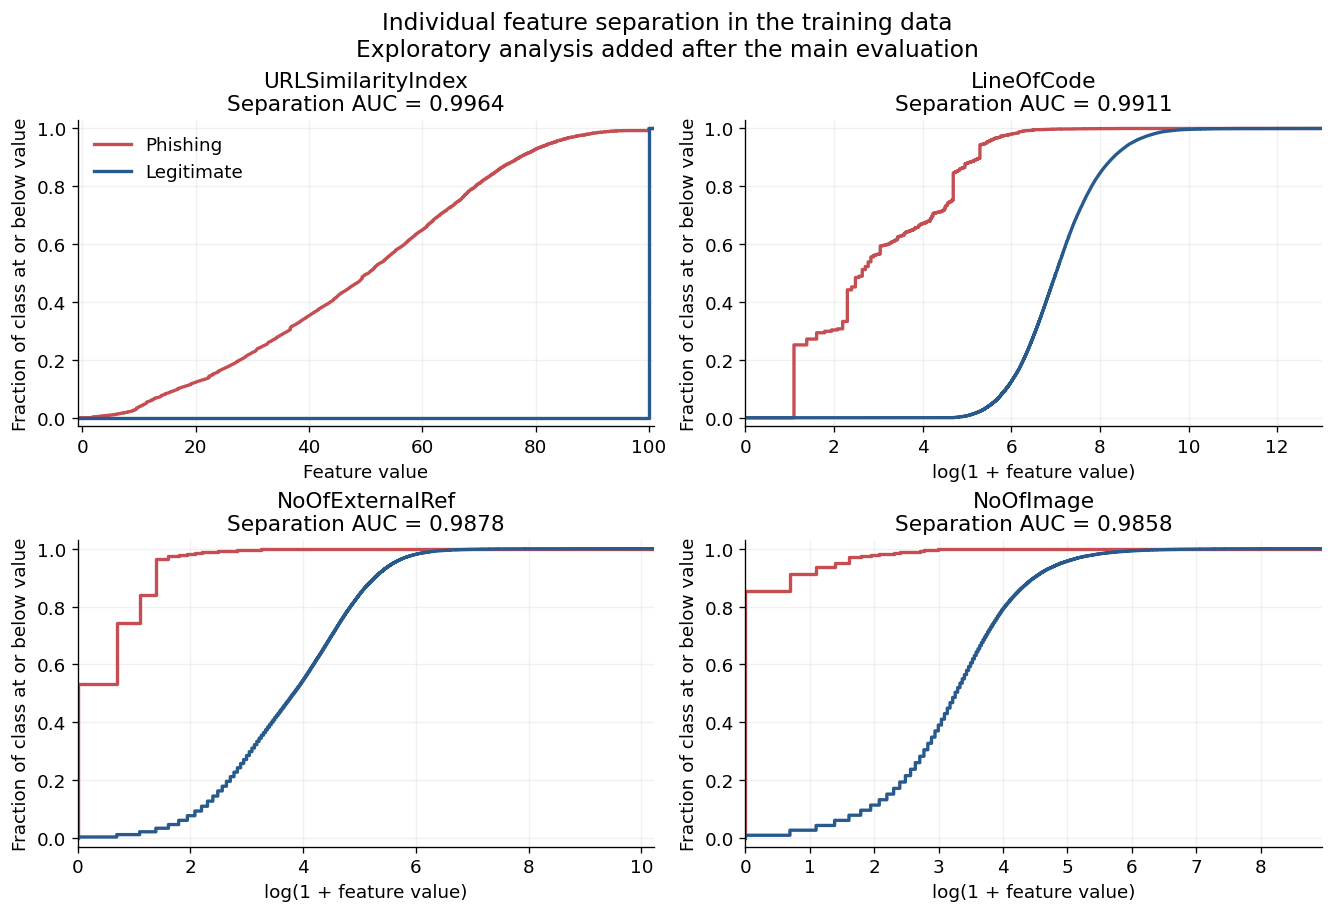

In [ ]:
# Exploratory diagnostic — training data only; no model fitting.

from sklearn.metrics import roc_auc_score

# Treat phishing as the positive class for this diagnostic.
training_phishing = (y_train.to_numpy() == 0).astype(int)

separation_rows = []

for feature in feature_columns:
    auc = roc_auc_score(
        training_phishing,
        X_train[feature].to_numpy()
    )

    separation_rows.append({
        "Feature": feature,
        "Separation AUC": max(auc, 1 - auc),
        "Phishing-associated direction": (
            "Higher values" if auc >= 0.5 else "Lower values"
        )
    })

feature_separation = (
    pd.DataFrame(separation_rows)
    .sort_values(
        ["Separation AUC", "Feature"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("INDIVIDUAL FEATURE SEPARATION — TRAINING DATA ONLY")
print("0.50 = no rank separation; 1.00 = perfect rank separation.")
print("Direction is assessed on training data; these are descriptive scores.")
display(feature_separation.head(12).round(6))

# Show USI plus the three strongest other features.
selected_features = ["URLSimilarityIndex"] + (
    feature_separation.loc[
        feature_separation["Feature"] != "URLSimilarityIndex",
        "Feature"
    ].head(3).tolist()
)

fig, axes = plt.subplots(
    2, 2, figsize=(11, 7.5),
    layout="constrained"
)

label_array = y_train.to_numpy()

for ax, feature in zip(axes.flat, selected_features):
    # Shared endpoints make constant-valued distributions visible.
    lower = float(X_train[feature].min())
    upper = float(X_train[feature].max())
    margin = max((upper - lower) * 0.01, 0.01)

    for label, class_name in [(0, "Phishing"), (1, "Legitimate")]:
        values = X_train.loc[
            label_array == label, feature
        ].to_numpy()

        unique_values, counts = np.unique(
            values, return_counts=True
        )
        cumulative = np.cumsum(counts) / counts.sum()

        plot_x = np.r_[lower - margin, unique_values, upper + margin]
        plot_y = np.r_[0.0, cumulative, 1.0]

        # log1p handles zero counts without negative tick clutter.
        if feature != "URLSimilarityIndex":
            plot_x = np.log1p(np.maximum(plot_x, 0))

        ax.step(
            plot_x, plot_y,
            where="post",
            color=CLASS_COLORS[class_name],
            linewidth=2,
            label=class_name
        )

    score = feature_separation.set_index("Feature").loc[
        feature, "Separation AUC"
    ]

    ax.set_title(f"{feature}\nSeparation AUC = {score:.4f}")
    ax.set_ylabel("Fraction of class at or below value")
    ax.set_ylim(-0.03, 1.03)
    ax.grid(alpha=0.18)

    if feature == "URLSimilarityIndex":
        ax.set_xlabel("Feature value")
        ax.set_xlim(lower - margin, upper + margin)
    else:
        ax.set_xlabel("log(1 + feature value)")
        ax.set_xlim(0, np.log1p(upper + margin))

axes[0, 0].legend(frameon=False, loc="best")

fig.suptitle(
    "Individual feature separation in the training data\n"
    "Exploratory analysis added after the main evaluation",
    fontsize=14
)

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"08_training_feature_separation.{extension}",
        bbox_inches="tight",
        facecolor="white"
    )

feature_separation.to_csv(
    FIGURE_DIR.parent / "training_feature_separation.csv",
    index=False
)

plt.show()

**Figure 8. Exploratory feature separation in the training data.**

URLSimilarityIndex, LineOfCode, NoOfExternalRef, and NoOfImage each show strong individual class separation, with direction-adjusted AUCs of 0.9964, 0.9911, 0.9878, and 0.9858, respectively. Lower values are associated with phishing. The strong separation in several remaining features is consistent with the high performance observed after removing URLSimilarityIndex. This helps explain the task’s overall ease, but does not establish the cause of the small differences between models or rule out collection-specific effects. This analysis was conducted after the main evaluation and did not change the experiments.